In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB


In [135]:
df=pd.read_csv(r'C:\Users\phani\OneDrive\Desktop\cardio_train (1).csv',sep=';')
df.head(7)

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
5,8,21914,1,151,67.0,120,80,2,2,0,0,0,0
6,9,22113,1,157,93.0,130,80,3,1,0,0,1,0


In [24]:
df['age']=df['age']/365

In [26]:
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,50.391781,2,168,62.0,110,80,1,1,0,0,1,0
1,1,55.419178,1,156,85.0,140,90,3,1,0,0,1,1
2,2,51.663014,1,165,64.0,130,70,3,1,0,0,0,1
3,3,48.282192,2,169,82.0,150,100,1,1,0,0,1,1
4,4,47.873973,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,52.712329,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,61.920548,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,52.235616,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,61.454795,1,163,72.0,135,80,1,2,0,0,0,1


In [28]:
df.drop('id',axis=1,inplace=True)


In [30]:
df.isnull().sum()


age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

In [32]:
df.duplicated().sum()

24

In [34]:
df = df.drop_duplicates()


In [38]:
df.duplicated().sum()

0

In [40]:
features=df.iloc[:,0:11]
features

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active
0,50.391781,2,168,62.0,110,80,1,1,0,0,1
1,55.419178,1,156,85.0,140,90,3,1,0,0,1
2,51.663014,1,165,64.0,130,70,3,1,0,0,0
3,48.282192,2,169,82.0,150,100,1,1,0,0,1
4,47.873973,1,156,56.0,100,60,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
69995,52.712329,2,168,76.0,120,80,1,1,1,0,1
69996,61.920548,1,158,126.0,140,90,2,2,0,0,1
69997,52.235616,2,183,105.0,180,90,3,1,0,1,0
69998,61.454795,1,163,72.0,135,80,1,2,0,0,0


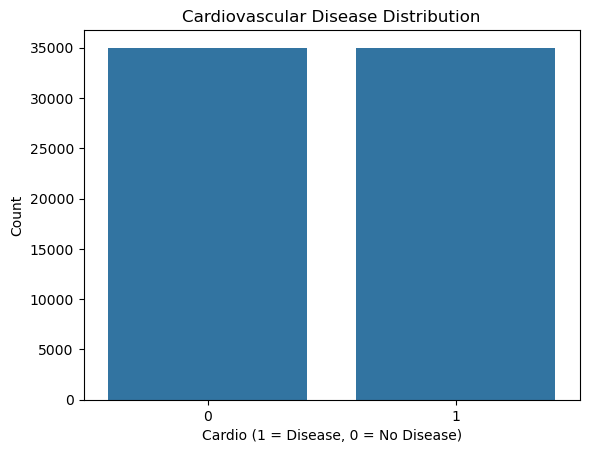

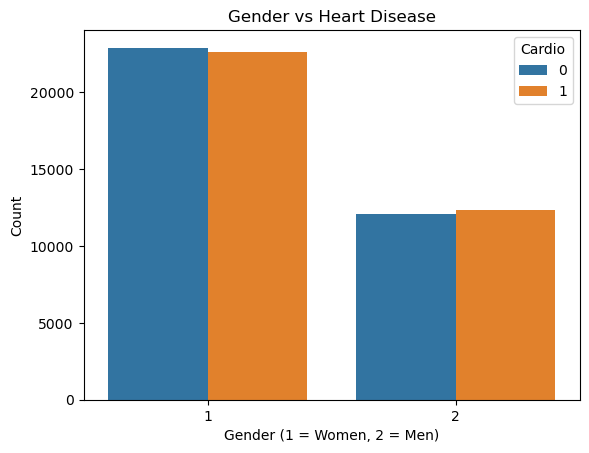

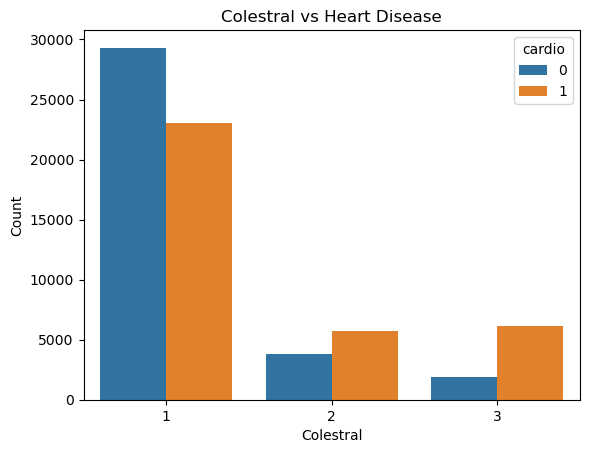

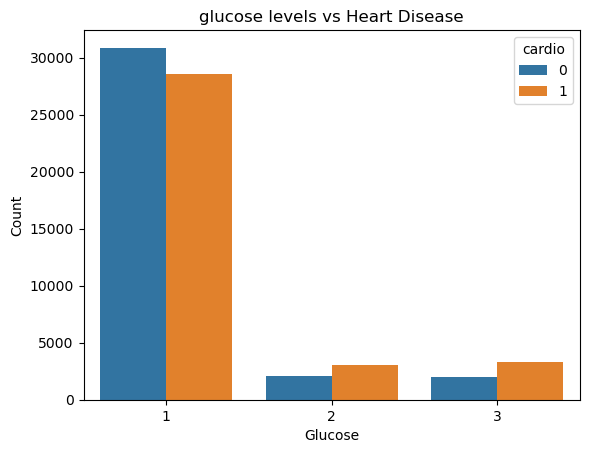

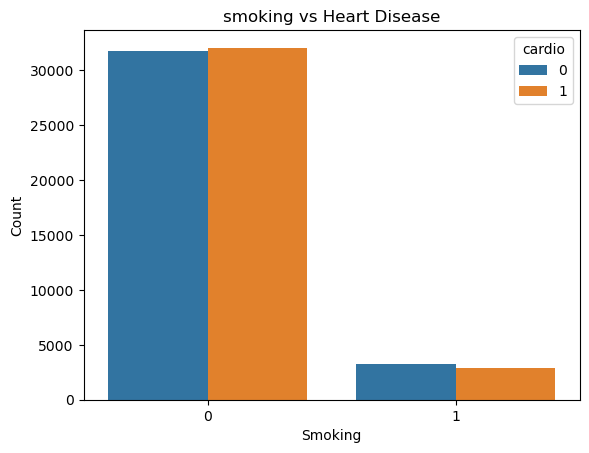

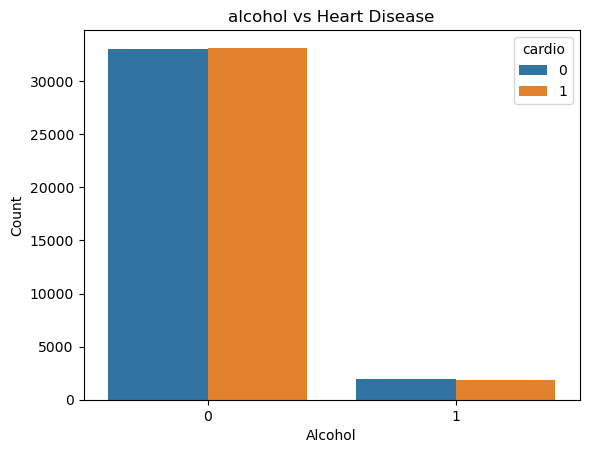

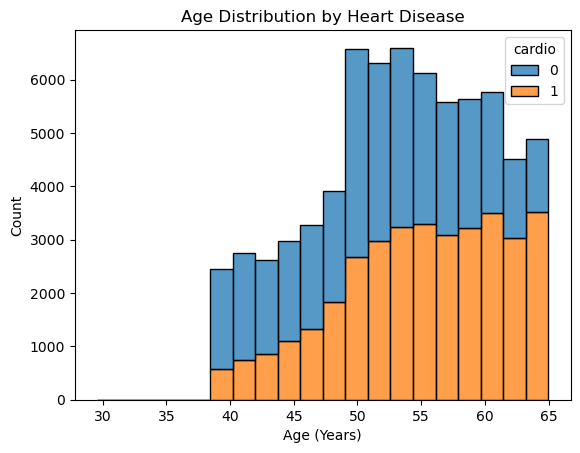

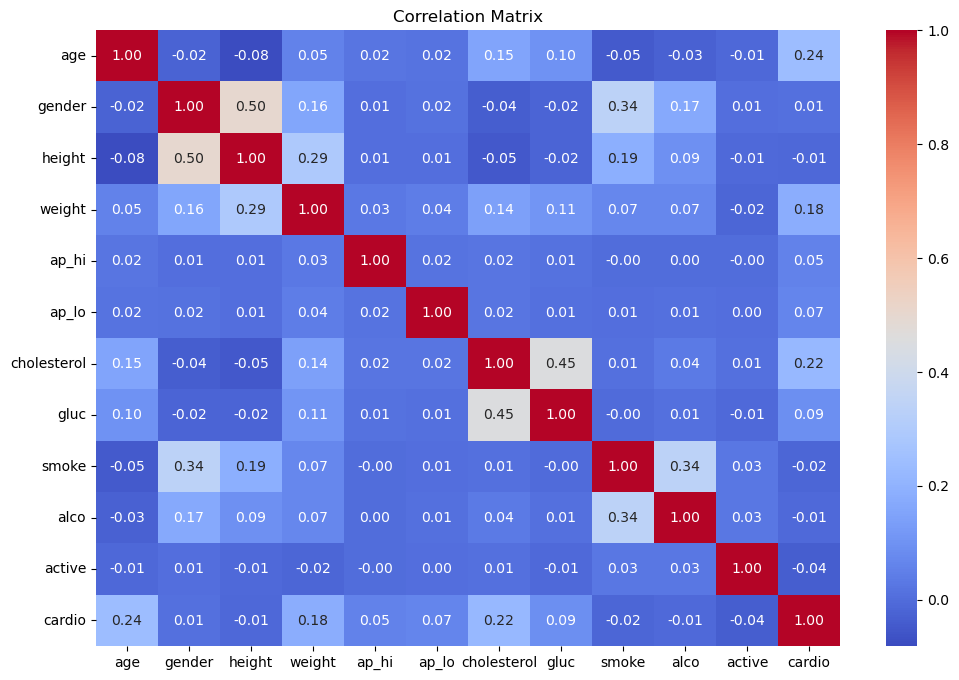

In [42]:
sns.countplot(x='cardio', data=df)
plt.title('Cardiovascular Disease Distribution')
plt.xlabel('Cardio (1 = Disease, 0 = No Disease)')
plt.ylabel('Count')
plt.show()

# Plot gender count
sns.countplot(x='gender', data=df, hue='cardio')
plt.title('Gender vs Heart Disease')
plt.xlabel('Gender (1 = Women, 2 = Men)')
plt.ylabel('Count')
plt.legend(title="Cardio")
plt.show()

#Colestral 
sns.countplot(x='cholesterol',data=df,hue='cardio')
plt.title('Colestral vs Heart Disease')
plt.xlabel('Colestral')
plt.ylabel('Count')
plt.show()

#glucose
sns.countplot(x='gluc',data=df,hue='cardio')
plt.title('glucose levels vs Heart Disease')
plt.xlabel('Glucose')
plt.ylabel('Count')
plt.show()

#smoking
sns.countplot(x='smoke',data=df,hue='cardio')
plt.title('smoking vs Heart Disease')
plt.xlabel('Smoking')
plt.ylabel('Count')
plt.show()

#alcohol
sns.countplot(x='alco',data=df,hue='cardio')
plt.title('alcohol vs Heart Disease')
plt.xlabel('Alcohol')
plt.ylabel('Count')
plt.show()


# Plot age distribution by target
sns.histplot(data=df, x='age', hue='cardio', multiple='stack', bins=20)
plt.title('Age Distribution by Heart Disease')
plt.xlabel('Age (Years)')
plt.show()



#Correlation Matrix
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

# --- Feature Scaling ---
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

#Input and Output
X = pd.DataFrame(scaled_features, columns=features.columns)
y = df[['cardio']]


In [250]:
df

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,50.391781,2,168,62.0,110,80,1,1,0,0,1,0
1,55.419178,1,156,85.0,140,90,3,1,0,0,1,1
2,51.663014,1,165,64.0,130,70,3,1,0,0,0,1
3,48.282192,2,169,82.0,150,100,1,1,0,0,1,1
4,47.873973,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
69995,52.712329,2,168,76.0,120,80,1,1,1,0,1,0
69996,61.920548,1,158,126.0,140,90,2,2,0,0,1,1
69997,52.235616,2,183,105.0,180,90,3,1,0,1,0,1
69998,61.454795,1,163,72.0,135,80,1,2,0,0,0,1


In [350]:
df.describe()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000
mean,53.339589,1.349648,164.359152,74.208519,128.820453,96.636261,1.366997,1.226535,0.088159,0.053790,0.803718,0.499771
std,6.759930,0.476862,8.211218,14.397211,154.037729,188.504581,0.680333,0.572353,0.283528,0.225604,0.397187,0.500004
min,29.583562,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,48.394521,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,53.980822,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,58.430137,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,64.967123,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [251]:
X

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active
0,-0.436074,1.363824,0.443402,-0.847984,-0.122182,-0.088255,-0.539441,-0.395798,-0.310938,-0.238428,0.494183
1,0.307637,-0.733233,-1.018023,0.749559,0.072577,-0.035205,2.400316,-0.395798,-0.310938,-0.238428,0.494183
2,-0.248018,-0.733233,0.078046,-0.709067,0.007658,-0.141304,2.400316,-0.395798,-0.310938,-0.238428,-2.023542
3,-0.748149,1.363824,0.565188,0.541184,0.137497,0.017844,-0.539441,-0.395798,-0.310938,-0.238428,0.494183
4,-0.808537,-0.733233,-1.018023,-1.264734,-0.187101,-0.194353,-0.539441,-0.395798,-0.310938,-0.238428,-2.023542
...,...,...,...,...,...,...,...,...,...,...,...
69971,-0.092792,1.363824,0.443402,0.124433,-0.057262,-0.088255,-0.539441,-0.395798,3.216080,-0.238428,0.494183
69972,1.269395,-0.733233,-0.774452,3.597353,0.072577,-0.035205,0.930437,1.351387,-0.310938,-0.238428,0.494183
69973,-0.163312,1.363824,2.270185,2.138727,0.332256,-0.035205,2.400316,-0.395798,-0.310938,4.194146,-2.023542
69974,1.200495,-0.733233,-0.165525,-0.153400,0.040117,-0.088255,-0.539441,1.351387,-0.310938,-0.238428,-2.023542


In [46]:
y

,cardio
0,0
1,1
2,1
3,1
4,0
...,...
69995,0
69996,1
69997,1
69998,1


In [50]:
x_train, x_test, y_train, y_test = train_test_split(X, y, train_size=0.85, random_state=42)

In [254]:
#KNN CLASSIFIER

In [437]:
knc=KNeighborsClassifier(n_neighbors=31)

In [439]:
knc.fit(x_train,y_train)

C:\Users\phani\anaconda3\Lib\site-packages\sklearn\neighbors\_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier(n_neighbors=31)

In [441]:
knc.score(x_test,y_test)

0.6684767076307516

In [258]:
y_pred_knn=knc.predict(x_test)

In [259]:
cm_knn=confusion_matrix(y_test,y_pred_knn)
cm_knn

array([[3429, 1746],
       [1952, 3370]], dtype=int64)

In [260]:
#RANDOM FOREST CLASSIFIER

In [352]:
rfc=RandomForestClassifier(n_estimators=500)

In [355]:
rfc.fit(x_train,y_train.values.ravel())

RandomForestClassifier(n_estimators=500)

In [357]:
rfc.score(x_test,y_test.values.ravel())

0.7112508335714967

In [264]:
y_pred_rfc=rfc.predict(x_test)

In [265]:
cm_rfc=confusion_matrix(y_test,y_pred_rfc)

In [266]:
#DECISION TREE CLASSIFIER

In [267]:
dtc=DecisionTreeClassifier()

In [268]:
dtc.fit(x_train,y_train)

DecisionTreeClassifier()

In [269]:
y_pred_dtc=dtc.predict(x_test)

In [270]:
dtc.score(x_test,y_test)

0.6311327045822616

In [271]:
cm_dtc=confusion_matrix(y_test, y_pred_dtc)
cm_dtc

array([[3294, 1881],
       [1991, 3331]], dtype=int64)

In [272]:
#LOGISTIC REGRESSION

In [273]:
lr=LogisticRegression()

In [274]:
lr.fit(x_train,y_train)

C:\Users\phani\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

In [275]:
y_pred_lr=lr.predict(x_test)

In [276]:
lr.score(x_test,y_test)

0.7163951605220539

In [277]:
cm_lr=confusion_matrix(y_test, y_pred_lr)
cm_lr

array([[3948, 1227],
       [1750, 3572]], dtype=int64)

In [278]:
#SUPPORT VECTOR CLASSIFIER

In [279]:
svc=SVC()

In [280]:
print(y_train.shape)

(59479, 1)


In [281]:
svc.fit(x_train, y_train.values.ravel())


SVC()

In [282]:
y_pred_svc=svc.predict(x_test)

In [283]:
svc.score(x_test,y_test)

0.7265885491092693

In [284]:
cm_svc=confusion_matrix(y_test, y_pred_svc)
cm_svc

array([[3931, 1244],
       [1626, 3696]], dtype=int64)

In [285]:
#NAVE BYERS CLASSIFIER

In [286]:
nb = GaussianNB()

In [287]:
nb.fit(x_train, y_train)

C:\Users\phani\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


GaussianNB()

In [288]:
y_pred_nb=nb.predict(x_test)

In [289]:
nb.score(x_test,y_test)

0.5865485376774316

In [290]:
cm_nb=cm_svc=confusion_matrix(y_test, y_pred_nb)
cm_nb

array([[4547,  628],
       [3712, 1610]], dtype=int64)

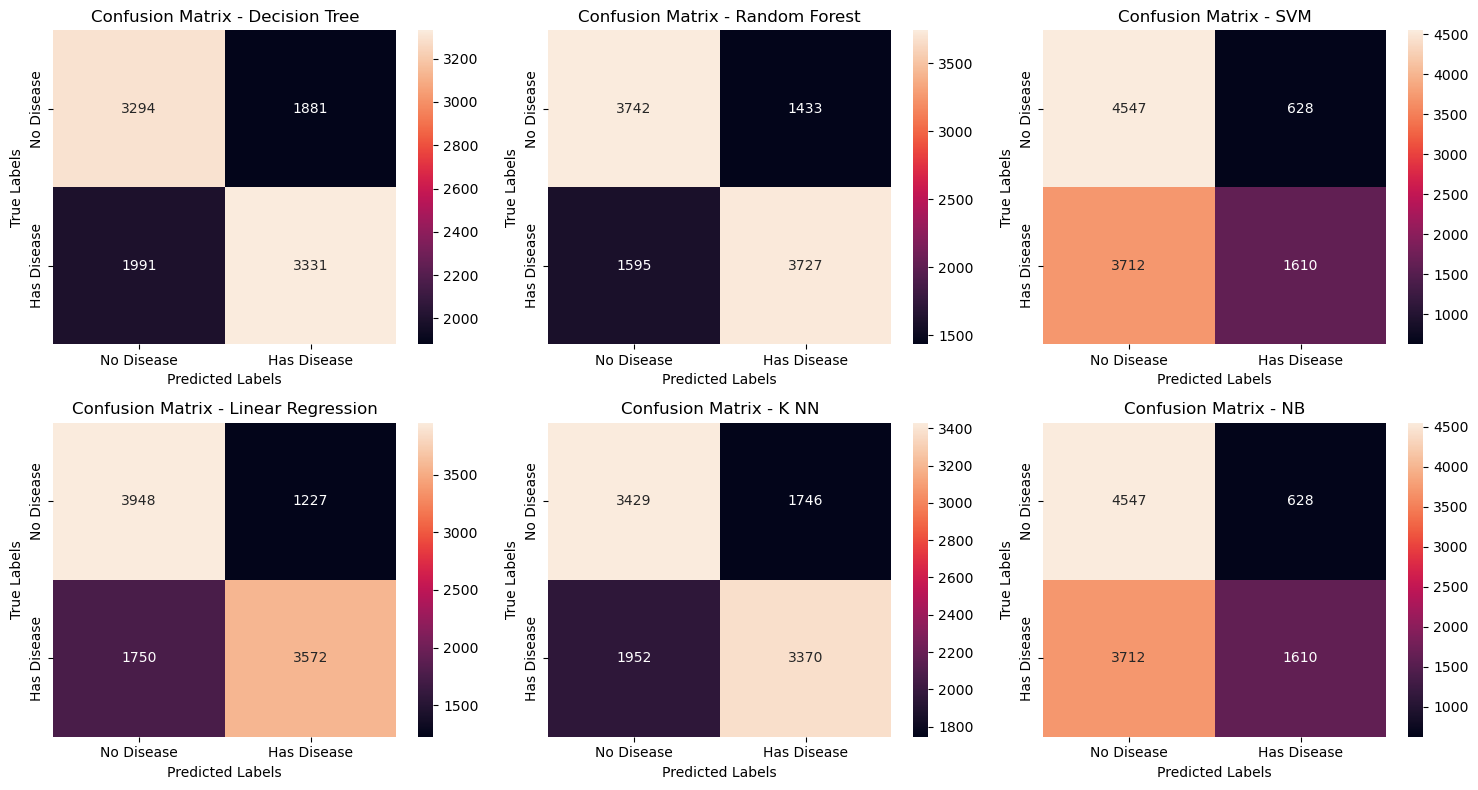

In [291]:
plt.figure(figsize=(15, 8))
plt.subplot(2, 3, 1)
sns.heatmap(cm_dtc, annot=True, fmt='d', 
            xticklabels=['No Disease', 'Has Disease'], 
            yticklabels=['No Disease', 'Has Disease'])
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

# Plot the confusion matrix for Random Forest
plt.subplot(2, 3, 2)
sns.heatmap(cm_rfc, annot=True, fmt='d', 
            xticklabels=['No Disease', 'Has Disease'], 
            yticklabels=['No Disease', 'Has Disease'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

# Plot the confusion matrix for SVM
plt.subplot(2, 3, 3)
sns.heatmap(cm_svc, annot=True, fmt='d', 
            xticklabels=['No Disease', 'Has Disease'], 
            yticklabels=['No Disease', 'Has Disease'])
plt.title('Confusion Matrix - SVM')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

plt.subplot(2, 3, 4)
sns.heatmap(cm_lr, annot=True, fmt='d', 
            xticklabels=['No Disease', 'Has Disease'], 
            yticklabels=['No Disease', 'Has Disease'])
plt.title('Confusion Matrix - Linear Regression')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

plt.subplot(2, 3, 5)
sns.heatmap(cm_knn, annot=True, fmt='d', 
            xticklabels=['No Disease', 'Has Disease'], 
            yticklabels=['No Disease', 'Has Disease'])
plt.title('Confusion Matrix - K NN')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

plt.subplot(2, 3, 6)
sns.heatmap(cm_nb, annot=True, fmt='d', 
            xticklabels=['No Disease', 'Has Disease'], 
            yticklabels=['No Disease', 'Has Disease'])
plt.title('Confusion Matrix - NB')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')


plt.tight_layout()
plt.show()


In [ ]:
# Accuracies
#K-Nearest Neighbours      - 66.8
#Random Forest Classifier  - 71.1
#Decision Tree Classifier  - 63.1
#Logistic Regression       - 71.6
#Support Vector Classifier - 72.6
#Nave Bayers               - 58.6

In [1]:
                                                   #CREATING MODEL USING SUPPORT VECTOR MACHINE

In [70]:
final_model=SVC()

In [72]:
final_model.fit(x_train,y_train)

C:\Users\phani\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC()

In [137]:
input_pre=pd.DataFrame([[22113	,1,	157	,93.0,	130	,80,	3,	1,	0,	0,	1		]])

In [106]:
print(type(input_pre))

<class 'pandas.core.frame.DataFrame'>


In [66]:
scaler.fit(x_train)

StandardScaler()

In [148]:
new_input=scaler.transform(input_pre)
new_input

C:\Users\phani\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[ 2.21084894e+04,  9.99617046e-01,  1.57353089e+02,
         9.32261144e+01,  1.24688406e+02,  7.95679606e+01,
         3.00808814e+00,  1.00157472e+00, -9.12159994e-04,
        -1.21613245e-04,  1.00037375e+00]])

In [143]:
print(final_model.predict(new_input))

[1]


C:\Users\phani\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
